In [ ]:
#librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#configuraciones visuales
sns.set_theme(style="whitegrid")

#leer dataset
df = pd.read_csv('C:\\Users\\cdiaziza\\Desktop\\projects\\data\\credit_risk_dataset.csv')
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [12]:
#revisión de tipo de datos y cantidad de nulos
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None

Valores nulos por columna

In [34]:
df.person_emp_length.quantile(np.arange(0.9,1.01,0.01))

0.90     10.0
0.91     11.0
0.92     11.0
0.93     11.0
0.94     12.0
0.95     13.0
0.96     13.0
0.97     14.0
0.98     15.0
0.99     18.0
1.00    123.0
Name: person_emp_length, dtype: float64

In [35]:
# Filtrar edades lógicas (menores de 100 años)
df = df[df['person_age'] <= 100]

# Filtrar años de experiencia lógicos (menores o iguales a 60 años)
df = df[df['person_emp_length'] <= 60]

df.shape

(31679, 12)

In [36]:
#imputacion de nulos

# Rellenar nulos con la mediana
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print("Nulos restantes:\n", df.isnull().sum())

Nulos restantes:
 person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


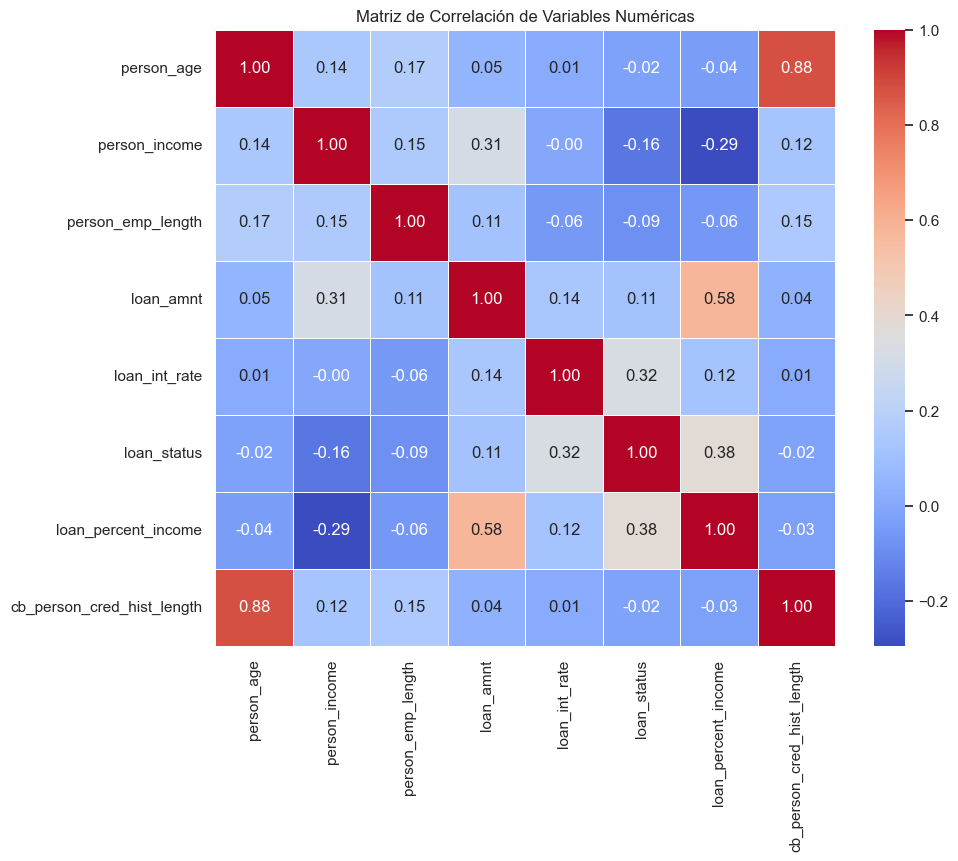

In [37]:
# variables numéricas para el analisis de correlación
num_cols = df.select_dtypes(include=[np.number])

# Crear matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [38]:
# Identificar variables categoricas
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Columnas a transformar:", cat_cols)

# One-Hot Encoding
# drop_first=True elimina la primera categoría para evitar multicolinealidad
df_clean = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Forzar a que todo sea numérico (convierte booleanos a 1 y 0)
df_clean = df_clean.astype(float)

display(df_clean.head())

Columnas a transformar: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21.0,9600.0,5.0,1000.0,11.14,0.0,0.10,2.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,25.0,9600.0,1.0,5500.0,12.87,1.0,0.57,3.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,23.0,65500.0,4.0,35000.0,15.23,1.0,0.53,2.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,24.0,54400.0,8.0,35000.0,14.27,1.0,0.55,4.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5,21.0,9900.0,2.0,2500.0,7.14,1.0,0.25,2.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
# Guardar en la carpeta data
df_clean.to_csv('C:\\Users\\cdiaziza\\Desktop\\projects\\data\\data_clean.csv', index=False)